# Exercise 2

In [ ]:
# check type for type hints (for ease of readability)
import numpy as np
x = np.random.randn(10, 10)
type(x[1][2])

numpy.float64

GridWorld

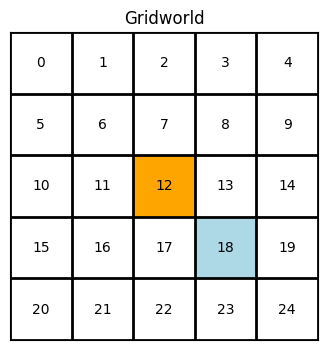

In [8]:
import GridWorld, RL_utils

gw = GridWorld.WaterFireGridWorld()
gw.plot_gridworld(print_states=True)

In [9]:
print("Conditional probablity distribution of gridworld: ")
gw.p

Conditional probablity distribution of gridworld: 


{(np.int64(0), 'U'): {(np.int64(0), -1.0): 1.0},
 (np.int64(0), 'D'): {(np.int64(5), -1.0): 1.0},
 (np.int64(0), 'L'): {(np.int64(0), -1.0): 1.0},
 (np.int64(0), 'R'): {(np.int64(1), -1.0): 1.0},
 (np.int64(1), 'U'): {(np.int64(1), -1.0): 1.0},
 (np.int64(1), 'D'): {(np.int64(6), -1.0): 1.0},
 (np.int64(1), 'L'): {(np.int64(0), -1.0): 1.0},
 (np.int64(1), 'R'): {(np.int64(2), -1.0): 1.0},
 (np.int64(2), 'U'): {(np.int64(2), -1.0): 1.0},
 (np.int64(2), 'D'): {(np.int64(7), -1.0): 1.0},
 (np.int64(2), 'L'): {(np.int64(1), -1.0): 1.0},
 (np.int64(2), 'R'): {(np.int64(3), -1.0): 1.0},
 (np.int64(3), 'U'): {(np.int64(3), -1.0): 1.0},
 (np.int64(3), 'D'): {(np.int64(8), -1.0): 1.0},
 (np.int64(3), 'L'): {(np.int64(2), -1.0): 1.0},
 (np.int64(3), 'R'): {(np.int64(4), -1.0): 1.0},
 (np.int64(4), 'U'): {(np.int64(4), -1.0): 1.0},
 (np.int64(4), 'D'): {(np.int64(9), -1.0): 1.0},
 (np.int64(4), 'L'): {(np.int64(3), -1.0): 1.0},
 (np.int64(4), 'R'): {(np.int64(4), -1.0): 1.0},
 (np.int64(5), 'U'):

### a. Implemtation of the Value Iteration Algorithm 

In [32]:
import GridWorld
from GridWorld import GridWorld
from numpy.typing import NDArray
from typing import Optional
import numpy as np

def value_iteration(gridworld: GridWorld, 
                    gamma: float = 0.95,
                    theta: float = 1e-8,
                    v_initial: Optional[NDArray[np.float64]] = None
    ) -> tuple[NDArray[np.float64], NDArray[np.int_], int]:
    
    if v_initial is None:
        V: NDArray[np.float64] = np.zeros(gridworld.nstates)
    else:
        V: NDArray[np.float64] = v_initial.copy()
    
    k = 0   # Iteration count

    # One way to see if the algorithm is learning is to see
    # the whole history of deltas. Ideally, over iterations
    # delta should be converging to 0

    deltas = []

    while True:
        delta: float = 0.0
        V_new: NDArray[np.float64] = np.zeros_like(V)

        for s in range(gridworld.nstates):      

            # Store action values for state s
            Q_s: NDArray[np.float64] = np.zeros(len(gridworld.actions))

            for a_idx, a in enumerate(gridworld.actions):
                
                Q_sa = 0.0

                for (next_state, r), prob in gridworld.p[(s, a)].items():
                    
                    Q_sa += prob * (r + gamma * V[next_state])

                Q_s[a_idx] = Q_sa

            V_new[s] = np.max(Q_s)
        
            delta = max(delta, abs(V[s] - V_new[s]))
            
        deltas.append(delta)
        V = V_new
        k += 1

        if delta < theta:
            break
    
    # Extract policy
    policy: NDArray[np.int_] = np.zeros((gridworld.nstates, 
                                        len(gridworld.actions)),
                                        dtype=int)

    for s in range(gridworld.nstates):

        Q_s: NDArray[np.float64] = np.zeros(len(gridworld.actions))

        for a_idx, a in enumerate(gridworld.actions):
            
            Q_sa = 0.0

            for (next_state, r), prob in gridworld.p[(s, a)].items():
                
                Q_sa += prob * (r + gamma * V[next_state])
            
            Q_s[a_idx] = Q_sa
        
        a_greedy = np.argmax(Q_s)
        policy[s, a_greedy] = 1.0
    return V, policy, k, deltas
                

    

7


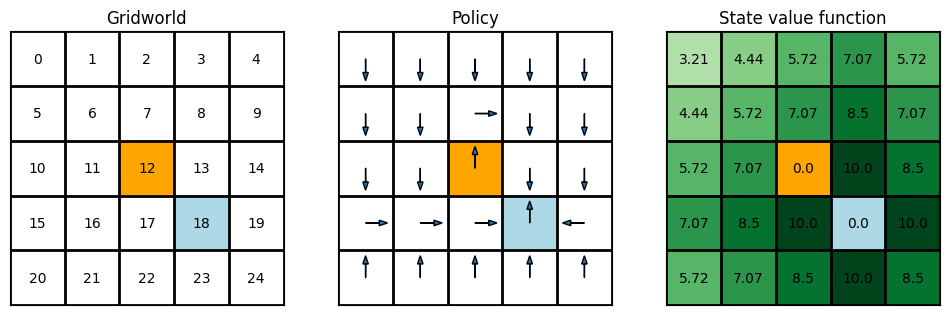

In [33]:
V_optimal, policy_optimal, iterations, deltas = value_iteration(gw)
print(iterations)
gw.plot_overview(policy=policy_optimal, v=V_optimal)

In [38]:
deltas

[np.float64(10.0),
 np.float64(9.5),
 np.float64(9.024999999999999),
 np.float64(8.573749999999999),
 np.float64(8.145062499999998),
 np.float64(7.737809374999998),
 0.0]

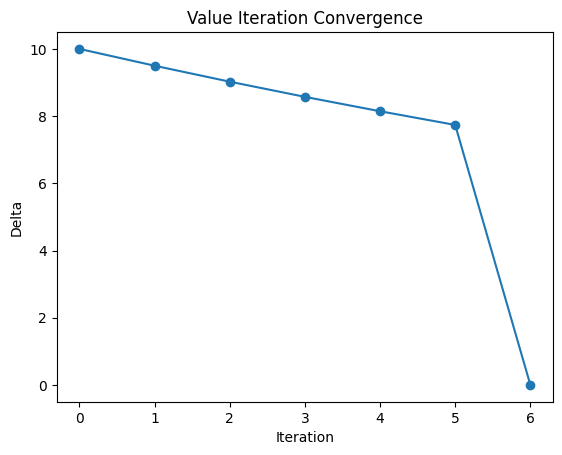

In [35]:
import matplotlib.pyplot as plt

plt.plot(deltas, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Value Iteration Convergence")
plt.show()

### b. Value Iteration vs Policy Iteration
In order to compare value iteration and policy iteration, I will implement policy iteration here. (Its implementation is copied from the seminar exercise)

In [42]:

# Copied from seminar exercise
def iterative_policy_evaluation(gridworld, policy, gamma=0.95, theta=1e-8, v_initial=None):
    """
    Iterative Policy Evaluation (Sutton & Barto)

    Args:
        gridworld: GridWorld environment (with transition model p)
        policy: (N x 4) array π(a|s)
        gamma: discount factor
        theta: convergence threshold
        v_initial: optional initial value function

    Returns:
        v_: value function (N,)
        k: number of iterations
    """

    if v_initial is None:
        v_ = np.zeros(gridworld.nstates)
    else:
        v_ = v_initial.copy()

    k = 0

    while True:
        delta = 0
        v_new = np.zeros_like(v_)

        # loop over all states
        for s in gridworld.states:

            v_s = 0.0

            # loop over actions
            for a_idx, a in enumerate(gridworld.actions):

                action_prob = policy[s, a_idx]

                # transition model
                for (s_next, r), prob in gridworld.p[(s, a)].items():

                    v_s += action_prob * prob * (r + gamma * v_[s_next])

            v_new[s] = v_s

            delta = max(delta, abs(v_new[s] - v_[s]))

        v_ = v_new
        k += 1

        if delta < theta:
            break

    return v_, k
def policy_iteration(gridworld: GridWorld, 
                     initial_policy: Optional[np.ndarray] = None, 
                     initial_policy_deterministic: bool = False, 
                     seed: Optional[int] = None, 
                     **kwargs
                     ) -> tuple[np.ndarray, np.ndarray, int]:
    
    if initial_policy is None:
        policy: NDArray[np.float64] = RL_utils.generate_random_policy(gridworld,
                                                deterministic=initial_policy_deterministic,
                                                seed=seed)
    else:
        policy: NDArray[np.float64] = initial_policy.copy()

    iterations: int = 0
    total_updates: int = 0

    V_: NDArray[np.float64] = np.zeros(gridworld.nstates)

    while True:

        # 1. Policy evaluation
        V, eval_updates = iterative_policy_evaluation(gridworld, policy)
        total_updates += eval_updates
        # 2. Policy Improvement
        new_policy: NDArray[np.float64] = RL_utils.greedy_policy(gridworld,
                                                                 V, 
                                                                 use_argmax=False)
        # 3. Convergence based on value functions
        delta = np.max(np.abs(V - V_))

        V_ = V.copy()
        policy = new_policy
        iterations += 1

        if delta < 1e-8:
            break
        
    return policy, V, iterations, total_updates

    

5


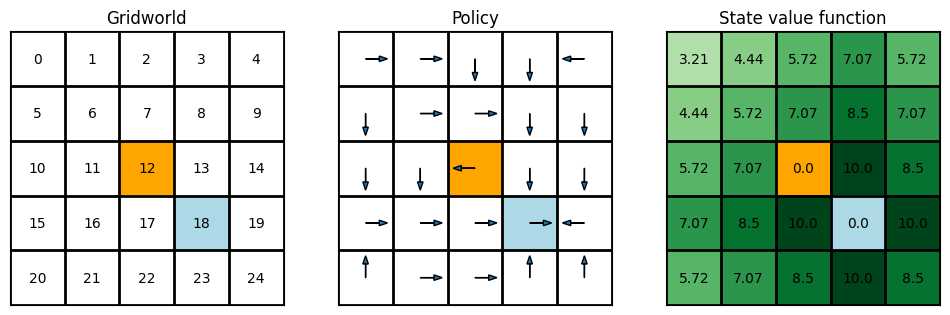

In [40]:
policy_optimal, v_optimal, iterations = policy_iteration(gw)
print(iterations)
gw.plot_overview(policy=policy_optimal, v=v_optimal)

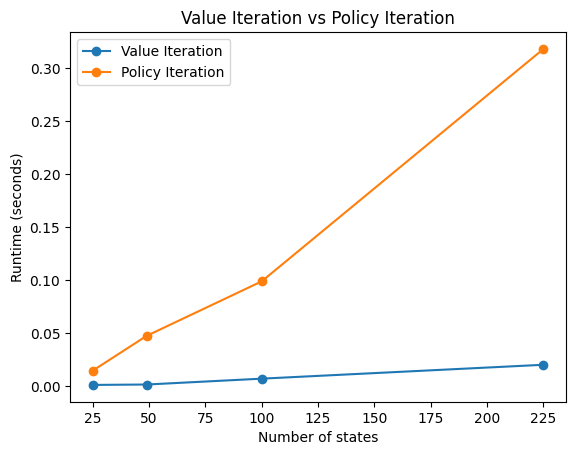

In [52]:
import time
from GridWorld import WaterFireGridWorld
def run_value_iteration(gw):
    start = time.time()
    _, _ , iterations, _ = value_iteration(gw)
    return time.time() - start, iterations

def run_policy_iteration(gw):
    start = time.time()
    _, _, iterations, updates = policy_iteration(gw)
    return  time.time() - start, updates


grid_dimensions = [5, 7, 10, 15]

vi_time, pi_time = [], []

vi_states, pi_states = [], []

for size in grid_dimensions:
    gw = WaterFireGridWorld(grid_size=(size, size))

    n_states = gw.nstates
    vi_states.append(n_states)
    pi_states.append(n_states)

    t_vi, _ = run_value_iteration(gw)
    t_pi, _ = run_policy_iteration(gw)

    vi_time.append(t_vi)
    pi_time.append(t_pi)

plt.plot(vi_states, vi_time, marker='o', label="Value Iteration")
plt.plot(pi_states, pi_time, marker='o', label="Policy Iteration")

plt.xlabel("Number of states")
plt.ylabel("Runtime (seconds)")
plt.title("Value Iteration vs Policy Iteration")
plt.legend()
plt.show()